# Lesson 13 activity: probability distributions

## Learning objectives

This activity will help you to:

1. Understand and apply binomial distributions to model discrete events
2. Demonstrate the Central Limit Theorem through sampling distributions
3. Visualize theoretical and empirical probability distributions
4. Connect statistical theory to real-world data analysis

## Setup

Import the required libraries and load the weather dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
# Load the weather dataset
url = 'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/weather.csv'
df = pd.read_csv(url)
df.head()

,weather_condition,wind_strength,temperature_c,rainfall_inches,humidity_percent,pressure_hpa
0,Sunny,Light Breeze,8.2,0.13,48.8,1016.5
1,Snowy,Gale,1.6,0.29,89.6,1009.4
2,Rainy,Strong Wind,7.3,0.01,100.0,1003.3
3,Cloudy,Light Breeze,21.6,0.62,49.3,1006.9
4,Sunny,Calm,12.0,1.09,38.6,1016.0


## Exercise 1: binomial distribution - modeling rainy days

**Objective**: Understand and visualize binomial distributions using real weather data.

The binomial distribution models the number of successes in a fixed number of independent trials. In weather forecasting, we can use it to model the probability of rainy days over a period of time.

**Tasks**:

1. **Calculate the probability of rain**:
   - Count how many days in the dataset have `rainfall_inches > 0`
   - Calculate the proportion of rainy days (this is your probability `p`)
   - Print this probability with an interpretation (e.g., "Based on our data, there's a X% chance of rain on any given day")

2. **Create a theoretical binomial distribution**:
   - Assume you're looking at a 30-day period (like a month)
   - Using the probability from step 1, calculate the theoretical probability of getting exactly k rainy days for k = 0, 1, 2, ..., 30
   - Use `scipy.stats.binom.pmf()`

3. **Visualize the distribution**:
   - Create a bar plot showing the probability of each possible number of rainy days (0 to 30)
   - Add a vertical line showing the expected value (mean = n × p)
   - Label the axes appropriately
   - Include a title with the probability of rain

4. **Interpret** your findings:
   - What is the most likely number of rainy days in a 30-day period?
   - What is the expected (mean) number of rainy days?
   - What's the probability of having 15 or more rainy days in a month?
   - How does this distribution help weather forecasters make predictions?
   - **Bonus**: Calculate the standard deviation and explain what it tells you about the variability in monthly rainfall patterns

Rainy days: 360 out of 365
Based on our data, there's a 98.6% chance of rain on any given day


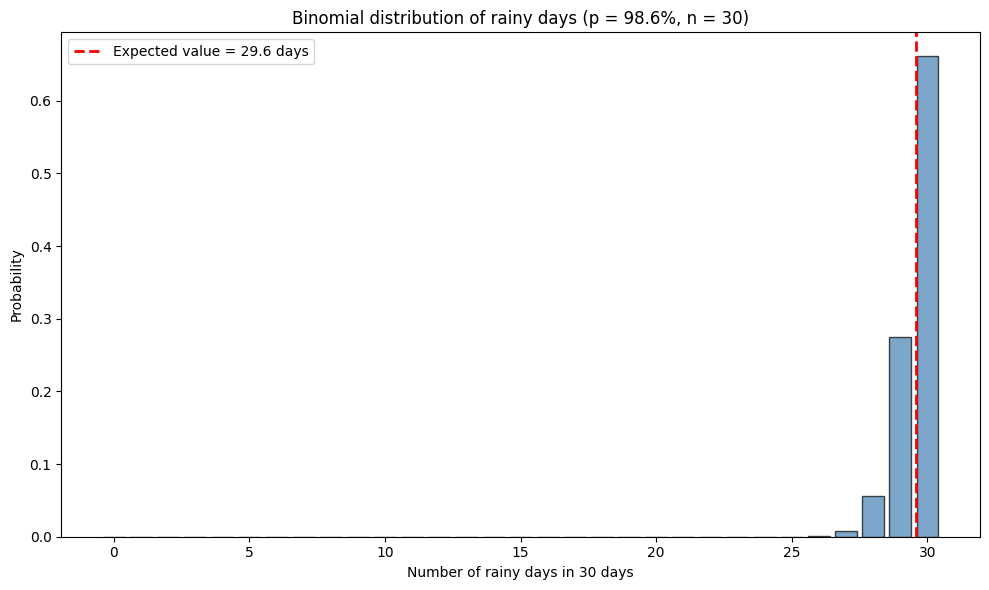

Most likely number of rainy days: 30
Expected (mean) number of rainy days: 29.59
Probability of 15 or more rainy days: 100.0%
Standard deviation: 0.64 days


In [5]:
# Your code here
# Task 1: probability of rain from the data
rainy_days = (df['rainfall_inches'] > 0).sum()
total_days = len(df)
p = rainy_days / total_days

print(f"Rainy days: {rainy_days} out of {total_days}")
print(f"Based on our data, there's a {p:.1%} chance of rain on any given day")

# Task 2: theoretical binomial over a 30-day month
n = 30
k = np.arange(0, n + 1)
pmf = stats.binom.pmf(k, n, p)

# Task 3: visualize
expected = n * p
plt.figure(figsize=(10, 6))
plt.bar(k, pmf, color='steelblue', edgecolor='black', alpha=0.7)
plt.axvline(expected, color='red', linestyle='--', linewidth=2,
            label=f'Expected value = {expected:.1f} days')
plt.xlabel('Number of rainy days in 30 days')
plt.ylabel('Probability')
plt.title(f'Binomial distribution of rainy days (p = {p:.1%}, n = 30)')
plt.legend()
plt.tight_layout()
plt.show()

# Task 4: interpretation
most_likely = k[np.argmax(pmf)]
prob_15_or_more = stats.binom.sf(14, n, p)   # P(X >= 15)
std_dev = np.sqrt(n * p * (1 - p))

print(f"Most likely number of rainy days: {most_likely}")
print(f"Expected (mean) number of rainy days: {expected:.2f}")
print(f"Probability of 15 or more rainy days: {prob_15_or_more:.1%}")
print(f"Standard deviation: {std_dev:.2f} days")

## Exercise 2: central limit theorem - sampling distribution of rainfall

**Objective**: Demonstrate the Central Limit Theorem by creating and analyzing a sampling distribution.

The Central Limit Theorem (CLT) states that the distribution of sample means approaches a normal distribution as the sample size increases, regardless of the population's original distribution. This is fundamental to statistical inference.

**Tasks**:

1. **Examine the population distribution**:
   - Create a histogram of all `rainfall_inches` values in the dataset
   - Calculate and print the population mean and standard deviation
   - Note the shape of this distribution (is it normal, skewed, etc.?)

2. **Create a sampling distribution**:
   - Take 1000 random samples from the rainfall data, each of size n=30
   - For each sample, calculate the mean rainfall
   - Store all 1000 sample means in a list or array
   - Hint: Use `df['rainfall_inches'].sample(n=30, replace=True)` for each sample

3. **Visualize the sampling distribution**:
   - Create a histogram of the 1000 sample means
   - Overlay a normal distribution curve using the theoretical mean (μ) and standard error (σ/√n)
   - Add a vertical line at the population mean
   - You can use `scipy.stats.norm.pdf()` to create the normal curve
   - Label axes and add a descriptive title

4. **Compare distributions**:
   - Create two side-by-side histograms:
     - Left: Original rainfall distribution (from step 1)
     - Right: Sampling distribution of means (from step 3)
   - Make sure both use the same y-axis scale for comparison
   - Include the mean and standard deviation in each subplot title

5. **Interpret** your findings:
   - How does the shape of the sampling distribution compare to the original distribution?
   - Is the sampling distribution approximately normal? (This demonstrates the CLT!)
   - Calculate the standard error: population σ divided by √30. How does this compare to the standard deviation of your sample means?
   - What does the CLT tell us about why we can use normal-based methods (like confidence intervals) even when our data isn't normally distributed?
   - **Bonus**: Repeat the experiment with different sample sizes (n=5, n=10, n=50). How does sample size affect the spread and normality of the sampling distribution?

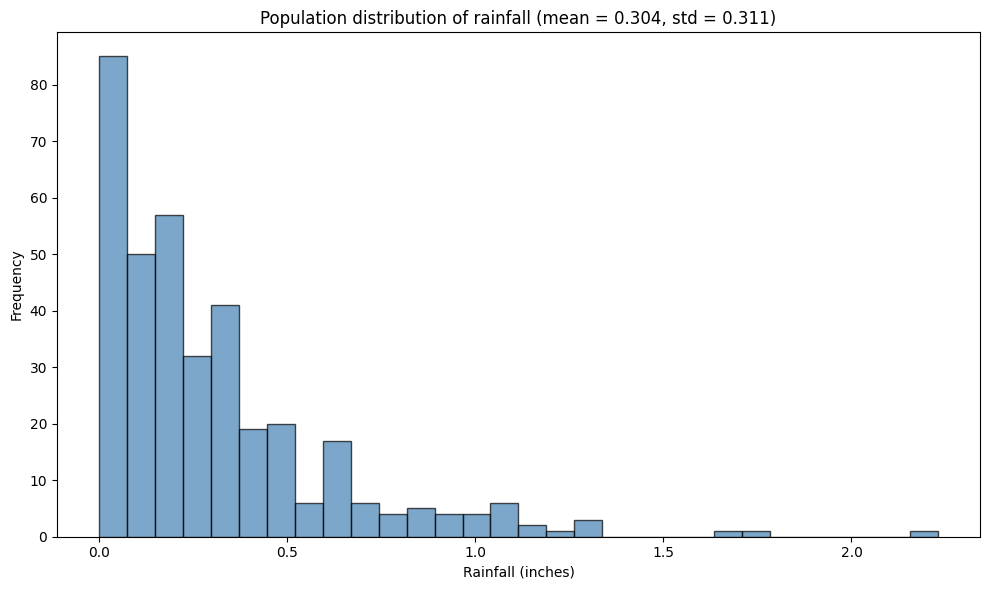

Population mean: 0.304 inches
Population std:  0.311 inches
Shape: right-skewed, most days have little or no rain with a long tail of heavy-rain days


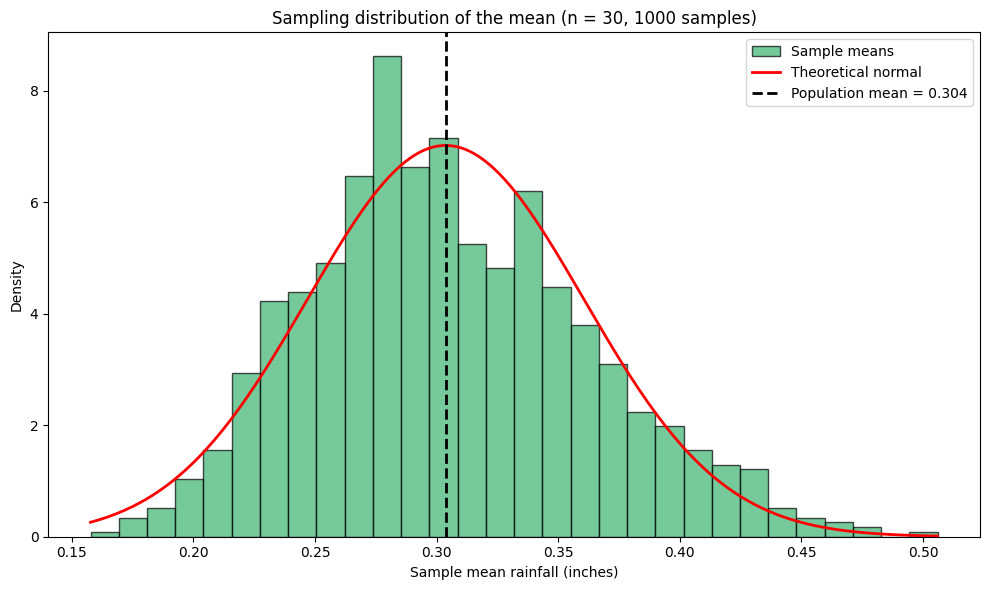

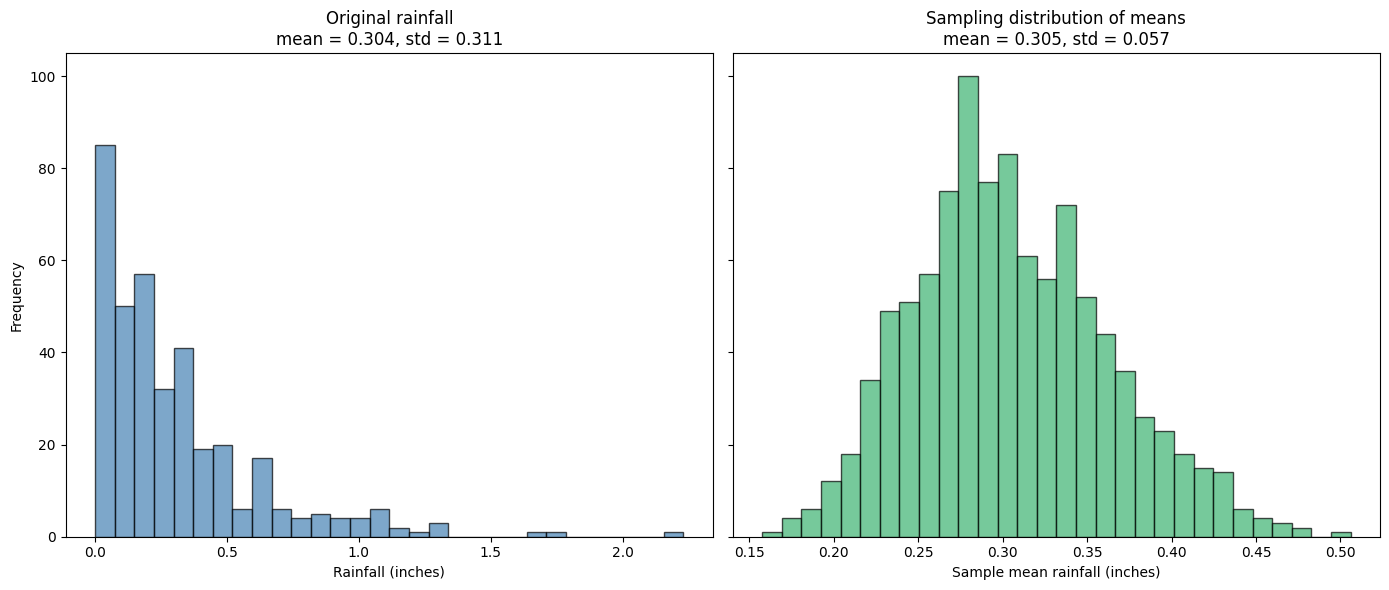

Standard error (population std / sqrt(n)): 0.0569
Std of the sample means (observed):        0.0574
These two should be close, confirming the CLT prediction.
The original data is right-skewed, but the sampling distribution of means is approximately normal.
That is why normal-based methods like confidence intervals work even when the underlying data is not normal:
it is the distribution of the sample mean that matters, and the CLT makes that approximately normal.


In [6]:
# Your code here
# Task 1: examine the population distribution
pop_mean = df['rainfall_inches'].mean()
pop_std = df['rainfall_inches'].std()

plt.figure(figsize=(10, 6))
plt.hist(df['rainfall_inches'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Rainfall (inches)')
plt.ylabel('Frequency')
plt.title(f'Population distribution of rainfall (mean = {pop_mean:.3f}, std = {pop_std:.3f})')
plt.tight_layout()
plt.show()

print(f"Population mean: {pop_mean:.3f} inches")
print(f"Population std:  {pop_std:.3f} inches")
print("Shape: right-skewed, most days have little or no rain with a long tail of heavy-rain days")

# Task 2: build the sampling distribution
n = 30
num_samples = 1000
sample_means = np.empty(num_samples)
for i in range(num_samples):
    sample_means[i] = df['rainfall_inches'].sample(n=n, replace=True).mean()

# Task 3: sampling distribution with a normal overlay
standard_error = pop_std / np.sqrt(n)

plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, color='mediumseagreen',
         edgecolor='black', alpha=0.7, label='Sample means')
x = np.linspace(sample_means.min(), sample_means.max(), 200)
plt.plot(x, stats.norm.pdf(x, pop_mean, standard_error),
         color='red', linewidth=2, label='Theoretical normal')
plt.axvline(pop_mean, color='black', linestyle='--', linewidth=2,
            label=f'Population mean = {pop_mean:.3f}')
plt.xlabel('Sample mean rainfall (inches)')
plt.ylabel('Density')
plt.title(f'Sampling distribution of the mean (n = {n}, {num_samples} samples)')
plt.legend()
plt.tight_layout()
plt.show()

# Task 4: side-by-side comparison, same y-axis scale
sm_mean = sample_means.mean()
sm_std = sample_means.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
axes[0].hist(df['rainfall_inches'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original rainfall\nmean = {pop_mean:.3f}, std = {pop_std:.3f}')
axes[0].set_xlabel('Rainfall (inches)')
axes[0].set_ylabel('Frequency')
axes[1].hist(sample_means, bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Sampling distribution of means\nmean = {sm_mean:.3f}, std = {sm_std:.3f}')
axes[1].set_xlabel('Sample mean rainfall (inches)')
plt.tight_layout()
plt.show()

# Task 5: interpretation
print(f"Standard error (population std / sqrt(n)): {standard_error:.4f}")
print(f"Std of the sample means (observed):        {sm_std:.4f}")
print("These two should be close, confirming the CLT prediction.")
print("The original data is right-skewed, but the sampling distribution of means is approximately normal.")
print("That is why normal-based methods like confidence intervals work even when the underlying data is not normal:")
print("it is the distribution of the sample mean that matters, and the CLT makes that approximately normal.")